In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
from utils import get_config
config = get_config()

In [10]:
num_classes = config['num_classes']
count_dict = {}

data_dir = config['dataset_dir']
p = Path(data_dir)
for file in p.rglob('*'):
    if file.is_file():
        label = file.parent.name
        if label in count_dict:
            count_dict[label] += 1
        else:
            count_dict[label] = 1

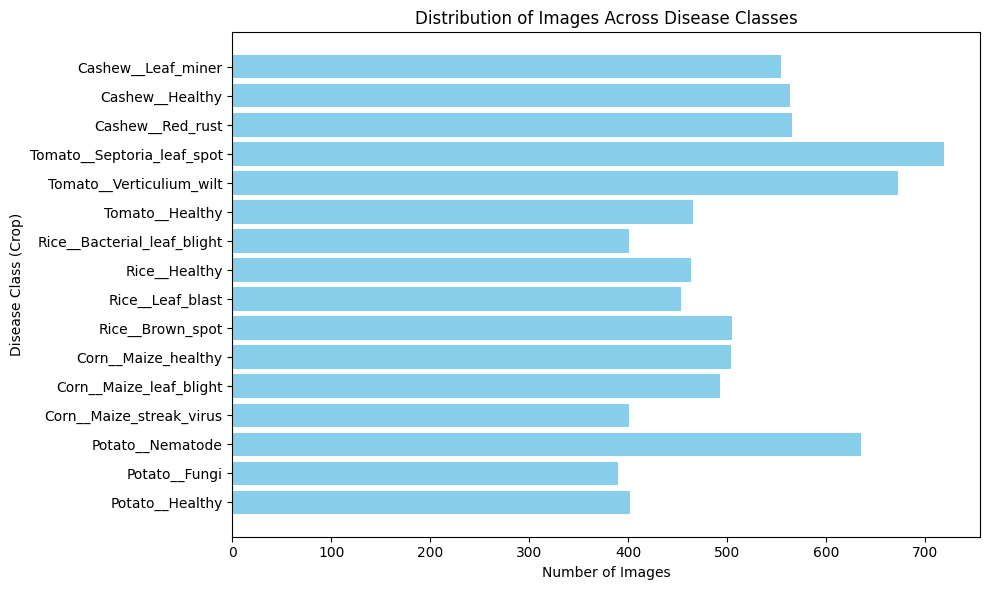

In [11]:
labels = list(count_dict.keys())
counts = list(count_dict.values())

plt.figure(figsize=(10, 6))
plt.barh(labels, counts, color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Disease Class (Crop)')
plt.title('Distribution of Images Across Disease Classes')
plt.tight_layout()
plt.show()

In [12]:
import csv

model_name = config['model_name']
with open(f'{model_name}/training_log.csv', 'r', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    epochs = []
    train_losses = []
    val_losses = []
    val_accuracies = []
    for row in reader:
        epochs.append(int(row['Epoch']))
        train_losses.append(float(row['Train Loss']))
        val_losses.append(float(row['Validation Loss']))
        val_accuracies.append(float(row['Validation Accuracy']))

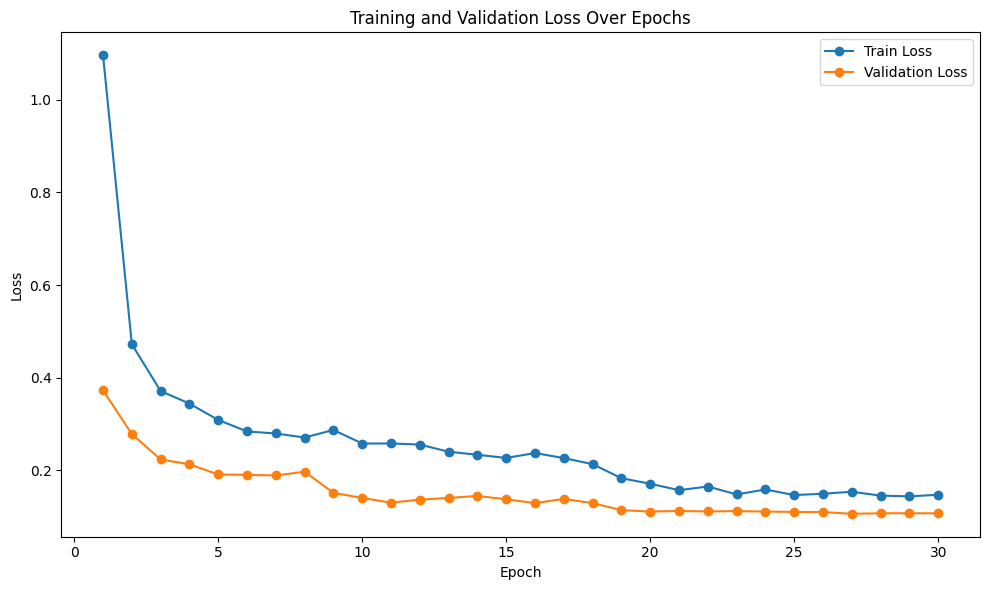

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

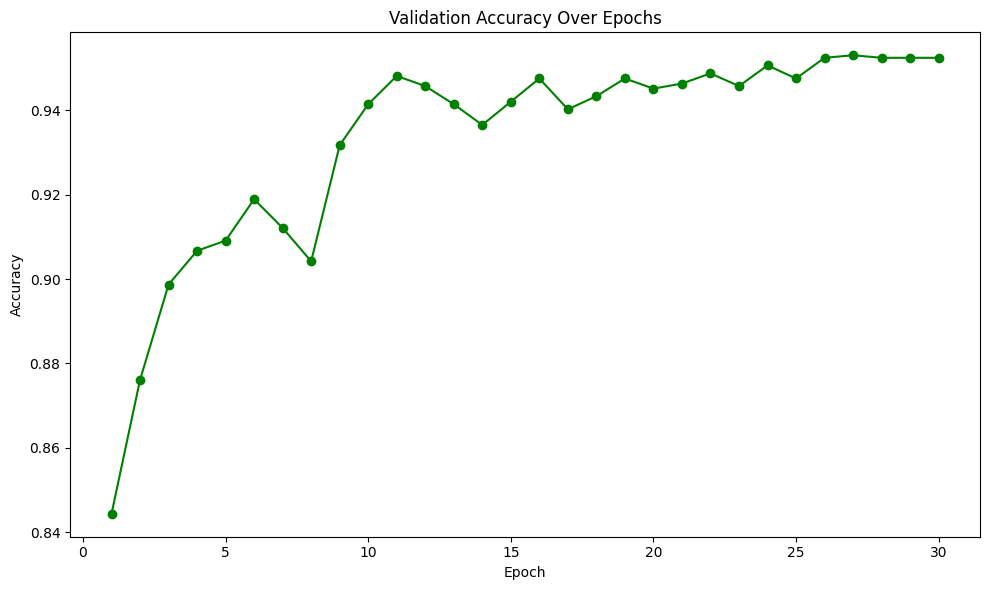

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.tight_layout()
plt.show()